# CMPE-257 | HW2 — Topic Modeling, Gemini & Chain of Thought
**ML Mavericks | Nikita**

**Poets: Robert Frost & Emily Dickinson**

---

This notebook builds directly on HW1. New things we add here:
1. Scrape 10 more poems (20 total per poet) for richer topic modeling
2. Consolidate all POS into one JSON pool
3. Analyze & adjust cosine similarity thresholds
4. Use **Gemini API** for smarter line-by-line transposition
5. **LDA topic modeling** + pyLDAvis visualization
6. **BART summarization** of original and transposed poems
7. Compare **Standard vs Chain of Thought vs Fractal CoT** prompting

---
### 🔑 Before you run this:
1. **Run HW1 first** — this notebook loads files HW1 saved to Drive
2. **Add your Gemini API key:**
   - In Colab, click the 🔑 key icon in the left sidebar (or go to Runtime → Manage Secrets)
   - Click "Add new secret"
   - Name: `GOOGLE_API_KEY`
   - Value: your key from [aistudio.google.com](https://aistudio.google.com)
   - Toggle "Notebook access" ON
3. Gemini features will be skipped gracefully if no key is found — everything else still runs!

## 📦 Install all dependencies

In [1]:
!pip3 install -q nltk sentence-transformers contractions pandas
!pip install -q gensim pyLDAvis spacy requests beautifulsoup4 lxml
!pip install -q google-generativeai
!python3 -m spacy download en_core_web_sm -q
print("All installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 55.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
All installed!


## 📚 Imports

In [2]:
import requests
import pandas as pd
import bs4 as bs
import urllib.request
import json, os, re, time, glob, warnings
import contractions
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sentence_transformers import SentenceTransformer, util

import spacy
import gensim
import gensim.corpora as corpora
from gensim.models import CoherenceModel
from gensim.utils import simple_preprocess
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

import google.generativeai as genai
from google.colab import drive, userdata

warnings.filterwarnings('ignore')
for pkg in ['stopwords','averaged_perceptron_tagger','universal_tagset',
            'wordnet','punkt','punkt_tab','averaged_perceptron_tagger_eng']:
    nltk.download(pkg, quiet=True)

nlp = spacy.load('en_core_web_sm')
print("All imports done!")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)
/usr/local/lib/python3.12/dist-packages/google/colab/html/_background_server.py:103: DeprecationWarning: make_current is deprecated; start the event loop first
  ioloop.make_current()


All imports done!


In [3]:
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## ⚙️ Configuration + Gemini setup

In [4]:
poet1 = "Robert Frost"
poet2 = "Emily Dickinson"
store_loc = "/content/drive/MyDrive/nlp-poets/Nikita/"
os.makedirs(store_loc, exist_ok=True)

# Try to set up Gemini — won't crash if key isn't there
gemini_model = None
try:
    GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
    genai.configure(api_key=GOOGLE_API_KEY)
    gemini_model = genai.GenerativeModel('gemini-2.5-flash')
    print("✅ Gemini API ready!")
except Exception as e:
    print(f"⚠️  Gemini not set up: {e}")
    print("   To enable Gemini: click the 🔑 icon in the left sidebar → Add GOOGLE_API_KEY")
    print("   Everything else in this notebook will still run fine.")

print(f"\nPoet 1: {poet1}")
print(f"Poet 2: {poet2}")

✅ Gemini API ready!

Poet 1: Robert Frost
Poet 2: Emily Dickinson


## 🔧 Redefine shared functions
We redefine the key functions from HW1 so this notebook is self-contained.

In [5]:
pd_title_list = ["Title", "Poem", "Poem_for_Human"]

def save_data_to_json(data, filename):
    filepath = os.path.join(store_loc, filename)
    with open(filepath, 'w', encoding='utf-8') as f:
        json.dump(data, f, indent=4)
    print(f"Saved to {filepath}")

def load_data_from_json(filename):
    filepath = os.path.join(store_loc, filename)
    if os.path.exists(filepath):
        with open(filepath, 'r', encoding='utf-8') as f:
            return json.load(f)
    return None

def pretty_print_poem(title, text, author):
    width = 62
    print("\n" + "═" * width)
    print(f"  📖  {title}\n  ✍️   {author}")
    print("═" * width)
    for line in str(text).strip().split('\n'):
        print(f"  {line}")
    print("═" * width + "\n")

def clean_txt(text):
    text = text.replace(u'\xa0', u' ').replace(r'\r', u'\n').replace('\n', ' ').replace('\t', ' ')
    text = contractions.fix(text)
    text = text.strip().lower()
    text = re.sub(r"'", ' ', text)
    filters = '!"\'\'#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'
    text = text.translate(str.maketrans(dict((i, " ") for i in filters)))
    return re.sub(' +', ' ', ' '.join([w for w in text.split() if len(w) > 1]))

def scrapePoemFromURL(poem_url_list):
    poems_results = []
    for url in poem_url_list:
        try:
            req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
            soup = bs.BeautifulSoup(urllib.request.urlopen(req).read(), 'html.parser')
            body = soup.find_all('div', class_="poem_body")
            if not body: continue
            poem_for_human = body[0].text.replace("© by owner. provided at no charge for educational purposes", "")
            poems_results.append([soup.find_all('h1')[0].text.strip(), clean_txt(poem_for_human), poem_for_human])
            time.sleep(0.5)
        except Exception as e:
            print(f"  Skipped {url}: {e}")
    return poems_results

def get_poem_url_json(poet, n=10):
    site, URL_list, page = "https://allpoetry.com", [], 1
    slug = poet.replace(" ", "+")
    while len(URL_list) < n:
        resp = requests.get(f"https://allpoetry.com/items/read_by/{slug}?page={page}",
                            headers={'User-Agent': 'Mozilla/5.0'})
        soup = bs.BeautifulSoup(resp.text, 'lxml')
        links = soup.find_all('a', href=True, class_='nocolor fn')
        for l in links:
            URL_list.append(site + l['href'])
            if len(URL_list) == n: break
        if not links: break
        page += 1
    return {"poet": poet, "URL": URL_list}

def getPoem(file_name, URLs):
    if os.path.exists(file_name):
        print(f"Loading from {file_name}")
        return pd.read_csv(file_name)
    os.makedirs(os.path.dirname(file_name), exist_ok=True)
    df = pd.DataFrame(scrapePoemFromURL(URLs), columns=pd_title_list)
    df.to_csv(file_name)
    print(f"Scraped and saved {len(df)} poems.")
    return df

def extract_pos_from_text(text):
    words = word_tokenize(str(text).lower())
    words = [w for w in words if w.isalpha() and w not in stopwords.words('english')]
    tagged_words = nltk.pos_tag(words, tagset='universal')
    return {
        'NOUN': [w for w, t in tagged_words if t == 'NOUN'],
        'VERB': [w for w, t in tagged_words if t == 'VERB'],
        'ADJ':  [w for w, t in tagged_words if t == 'ADJ'],
        'ADV':  [w for w, t in tagged_words if t == 'ADV']
    }

def getSemanticSimilarity(p1, p2, model):
    e1 = model.encode(str(p1), convert_to_tensor=True)
    e2 = model.encode(str(p2), convert_to_tensor=True)
    return util.pytorch_cos_sim(e1, e2).item()

print("Functions defined.")

Functions defined.


## 📖 Load HW1 data + scrape 10 more poems (20 total)

In [6]:
# Load the original 10 poems from HW1
file_name = store_loc + poet1.replace(" ", "_") + ".csv"
RF_df = getPoem(file_name, get_poem_url_json(poet1, 10)['URL'])

file_name = store_loc + poet2.replace(" ", "_") + ".csv"
ED_df = getPoem(file_name, get_poem_url_json(poet2, 10)['URL'])

# Load HW1 POS JSONs
RF_pos = load_data_from_json(poet1.replace(" ", "_") + ".json")
ED_pos = load_data_from_json(poet2.replace(" ", "_") + ".json")

if RF_pos is None or ED_pos is None:
    print("\n⚠️  HW1 POS data not found! Make sure you ran HW1 first and it saved files to the same Drive folder.")
else:
    print(f"✅ HW1 data loaded — {len(RF_df)} Frost poems, {len(ED_df)} Dickinson poems")

Loading from /content/drive/MyDrive/nlp-poets/Nikita/Robert_Frost.csv
Loading from /content/drive/MyDrive/nlp-poets/Nikita/Emily_Dickinson.csv
✅ HW1 data loaded — 10 Frost poems, 10 Dickinson poems


In [7]:
# Now scrape 10 MORE poems (total = 20 per poet)
# We save these as separate files so they don't conflict with HW1
file_name = store_loc + poet1.replace(" ", "_") + "_20poems.csv"
RF_df_20 = getPoem(file_name, get_poem_url_json(poet1, 20)['URL'])

file_name = store_loc + poet2.replace(" ", "_") + "_20poems.csv"
ED_df_20 = getPoem(file_name, get_poem_url_json(poet2, 20)['URL'])

print(f"\n{poet1}: {len(RF_df_20)} poems total")
print(f"{poet2}: {len(ED_df_20)} poems total")

Loading from /content/drive/MyDrive/nlp-poets/Nikita/Robert_Frost_20poems.csv
Loading from /content/drive/MyDrive/nlp-poets/Nikita/Emily_Dickinson_20poems.csv

Robert Frost: 20 poems total
Emily Dickinson: 20 poems total


## 🗂️ Consolidate POS into one JSON pool

In [8]:
# Build a single consolidated POS pool from all 20 poems per poet
# This is richer than the per-poem data and gives us better swaps

consolidated_pos_file = store_loc + "consolidated_pos_pool.json"

if os.path.exists(consolidated_pos_file):
    print("Loading existing consolidated POS pool...")
    with open(consolidated_pos_file, 'r', encoding='utf-8') as f:
        consolidated_pos = json.load(f)
else:
    print("Building consolidated POS pool from 20 poems each...")

    poet1_text = " ".join(RF_df_20['Poem_for_Human'].astype(str).tolist())
    poet2_text = " ".join(ED_df_20['Poem_for_Human'].astype(str).tolist())

    def extract_and_consolidate_pos(text):
        words = word_tokenize(text.lower())
        words = [w for w in words if w.isalpha() and w not in stopwords.words('english')]
        tagged = nltk.pos_tag(words, tagset='universal')
        return {
            'NOUN': list(set([w for w, t in tagged if t == 'NOUN'])),
            'VERB': list(set([w for w, t in tagged if t == 'VERB'])),
            'ADJ':  list(set([w for w, t in tagged if t == 'ADJ']))
        }

    consolidated_pos = {
        poet1: extract_and_consolidate_pos(poet1_text),
        poet2: extract_and_consolidate_pos(poet2_text)
    }

    save_data_to_json(consolidated_pos, "consolidated_pos_pool.json")
    print("Consolidated POS pool saved!")

p1_pool = consolidated_pos[poet1]
p2_pool = consolidated_pos[poet2]

print(f"\n{poet1}: {len(p1_pool['NOUN'])} nouns, {len(p1_pool['VERB'])} verbs, {len(p1_pool['ADJ'])} adjectives")
print(f"{poet2}: {len(p2_pool['NOUN'])} nouns, {len(p2_pool['VERB'])} verbs, {len(p2_pool['ADJ'])} adjectives")

Loading existing consolidated POS pool...

Robert Frost: 423 nouns, 282 verbs, 224 adjectives
Emily Dickinson: 274 nouns, 169 verbs, 127 adjectives


## 📊 Analyze cosine similarity thresholds

In [9]:
print("Loading similarity model...")
sim_model = SentenceTransformer('all-MiniLM-L6-v2')
print("Ready!")

Loading similarity model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Ready!


In [10]:
# Test similarity between specific word pairs to understand our threshold
# This helps us decide what threshold to use in swapWords()

def analyze_similarity(word1, word2, threshold=0.3):
    embeddings = sim_model.encode([word1, word2])
    cos_sim = util.cos_sim(embeddings[0], embeddings[1]).item()
    status = "✅ Accepted" if cos_sim >= threshold else "❌ Rejected"
    print(f"  '{word1}' vs '{word2}': {cos_sim:.4f}  →  {status} (threshold={threshold})")
    return cos_sim


print("Testing similarity between word pairs from our poets' vocabularies:\n")

# Frost-style words vs Dickinson-style words
analyze_similarity("road",     "path",      threshold=0.4)
analyze_similarity("snow",     "frost",     threshold=0.4)
analyze_similarity("woods",    "forest",    threshold=0.4)
analyze_similarity("death",    "dying",     threshold=0.4)
analyze_similarity("immortal", "eternal",   threshold=0.4)
analyze_similarity("road",     "eternity",  threshold=0.4)  # should be low

print("\nObservation: adjust the threshold in swapWords() based on these scores.")
print("0.3 = more swaps (looser) | 0.7 = fewer swaps (stricter)")

Testing similarity between word pairs from our poets' vocabularies:

  'road' vs 'path': 0.6199  →  ✅ Accepted (threshold=0.4)
  'snow' vs 'frost': 0.6702  →  ✅ Accepted (threshold=0.4)
  'woods' vs 'forest': 0.8166  →  ✅ Accepted (threshold=0.4)
  'death' vs 'dying': 0.8610  →  ✅ Accepted (threshold=0.4)
  'immortal' vs 'eternal': 0.7435  →  ✅ Accepted (threshold=0.4)
  'road' vs 'eternity': 0.3255  →  ❌ Rejected (threshold=0.4)

Observation: adjust the threshold in swapWords() based on these scores.
0.3 = more swaps (looser) | 0.7 = fewer swaps (stricter)


## 🤖 Gemini API — smarter line-by-line transposition

In [11]:
def swapWord_gemini(original_word, pos_tag, target_poet, context_line):
    """
    Ask Gemini to pick the best replacement for a word.
    Unlike cosine similarity, Gemini understands the full context of the line.
    """
    if not gemini_model:
        return original_word
    prompt = (
        f"Rewrite the word '{original_word}' ({pos_tag}) in this line: '{context_line}'. "
        f"Make it sound like it was written by {target_poet}. Return only the new word."
    )
    try:
        response = gemini_model.generate_content(prompt)
        result = response.text.strip().split()[0]  # take just the first word
        print(f"  [Gemini] '{original_word}' → '{result}'")
        return result
    except Exception as e:
        print(f"  [Gemini] Error for '{original_word}': {e}")
        return original_word


def transpose_poem_line_by_line(poem_text, target_poet, target_pos_list=None):
    """
    Go through the poem line by line and use Gemini to replace each
    noun, verb, and adjective with a word in the target poet's style.
    """
    if target_pos_list is None:
        target_pos_list = ['NN', 'NNS', 'VB', 'VBD', 'VBG', 'JJ']

    transposed_lines = []
    for line in poem_text.strip().split('\n'):
        tokens = word_tokenize(line)
        pos_tags = nltk.pos_tag(tokens)
        new_tokens = []
        for word, tag in pos_tags:
            if tag in target_pos_list and word.isalpha():
                new_word = swapWord_gemini(word, tag, target_poet, line)
                new_tokens.append(new_word)
            else:
                new_tokens.append(word)
        transposed_lines.append(" ".join(new_tokens))
    return "\n".join(transposed_lines)


print("Gemini transposition functions defined.")

Gemini transposition functions defined.


In [12]:
# Run Gemini transposition on Poem 0 of Frost → Dickinson style
gemini_out_file = store_loc + f"gemini_{poet1.replace(' ','_')}-{poet2.replace(' ','_')}-poem0.txt"

if gemini_model:
    if os.path.exists(gemini_out_file):
        print("Loading saved Gemini transposition...")
        with open(gemini_out_file) as f:
            gemini_poem = f.read()
    else:
        poem0_text = str(RF_df.iloc[0]['Poem_for_Human'])
        print(f"Running Gemini transposition on {poet1} Poem 0 → {poet2} style...")
        print("(This makes one API call per word in the poem — may take a minute)")
        gemini_poem = transpose_poem_line_by_line(poem0_text, poet2)
        with open(gemini_out_file, 'w') as f:
            f.write(gemini_poem)
        print("\nSaved!")

    pretty_print_poem(f"Poem 0 — Gemini transposition ({poet1} → {poet2})", gemini_poem, poet1)
else:
    print("⚠️  Gemini not configured. Add GOOGLE_API_KEY to Colab Secrets to use this.")
    gemini_poem = None

Running Gemini transposition on Robert Frost Poem 0 → Emily Dickinson style...
(This makes one API call per word in the poem — may take a minute)


ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1158.41ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 878.02ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1329.96ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 8397.94ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 2219.73ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1625.80ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 3327.44ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding

  [Gemini] 'world' → 'Existence'
  [Gemini] 'end' → 'Expire'


ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1519.44ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 2656.61ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 5391.94ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1190.03ms


  [Gemini] 'fire' → 'Ardor'


...

  [Gemini] 'had' → 'Were'


ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1063.66ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 836.24ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 4630.54ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1113.60ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 7940.55ms


  [Gemini] 'perish' → 'Dissolve'


ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1543.51ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1062.71ms


  [Gemini] 'hate' → 'Rancor'
  [Gemini] 'say' → 'Know'
  [Gemini] 'destruction' → 'Dissolution'
  [Gemini] 'ice' → 'Frost'
  [Gemini] 'great' → 'Vast'
  [Gemini] 'suffice' → 'Content'
  [Gemini] 'analysis' → 'Soul'

Saved!

══════════════════════════════════════════════════════════════
  📖  Poem 0 — Gemini transposition (Robert Frost → Emily Dickinson)
  ✍️   Robert Frost
══════════════════════════════════════════════════════════════
  Some say the Existence will Expire in Ardor ,
  Some say in ice .
  From what I 've tasted of Thirst
  I hold with those who favor Ardor .
  But if it Were to Dissolve twice ,
  I think I know enough of Rancor
  To Know that for Dissolution Frost
  Is also Vast
  And would Content . Show Soul
══════════════════════════════════════════════════════════════



## 📝 BART Summarization
We summarize both the original and transposed poems to see how meaning changes.

In [13]:
# Load BART for summarization — using t5-base which is more reliable across transformers versions
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

print("Loading T5 summarizer (this may take a minute the first time)...")
t5_tokenizer = AutoTokenizer.from_pretrained("t5-base")
t5_model = AutoModelForSeq2SeqLM.from_pretrained("t5-base")
print("Ready!")

Loading T5 summarizer (this may take a minute the first time)...


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

Ready!


In [14]:
def summarize_poem(text, max_length=60, min_length=10):
    """Summarize a poem using T5. Works better than BART on newer transformers versions."""
    if not text or len(str(text).split()) < 20:
        return "(too short to summarize)"
    try:
        inputs = t5_tokenizer(
            "summarize: " + str(text),
            return_tensors="pt", max_length=512, truncation=True
        )
        outputs = t5_model.generate(
            inputs.input_ids,
            attention_mask=inputs.attention_mask,
            max_length=max_length,
            min_length=min_length,
            num_beams=4,
            early_stopping=True
        )
        return t5_tokenizer.decode(outputs[0], skip_special_tokens=True)
    except Exception as e:
        return f"(summarization error: {e})"


# Summarize original poem 0 from each poet
poem0_rf = str(RF_df.iloc[0]['Poem_for_Human'])
poem0_ed = str(ED_df.iloc[0]['Poem_for_Human'])

# Load transposed poem from HW1 if it exists
hw1_transposed_file = store_loc + f"{poet1.replace(' ','_')}-{poet2.replace(' ','_')}-poem0.txt"
poem0_transposed = poem0_rf  # fallback
if os.path.exists(hw1_transposed_file):
    with open(hw1_transposed_file) as f:
        poem0_transposed = f.read()

print(f"📝 Summary — Original {poet1} Poem 0:")
print(f"   {summarize_poem(poem0_rf)}\n")

print(f"📝 Summary — Transposed (cosine similarity) {poet1}→{poet2}:")
print(f"   {summarize_poem(poem0_transposed)}\n")

if gemini_poem:
    print(f"📝 Summary — Transposed (Gemini) {poet1}→{poet2}:")
    print(f"   {summarize_poem(gemini_poem)}\n")

print(f"📝 Summary — Original {poet2} Poem 0:")
print(f"   {summarize_poem(poem0_ed)}")

📝 Summary — Original Robert Frost Poem 0:
   bob greene: some say the world will end in fire, others say in ice . greene: if it had to perish twice, ice would suffice for destruction . he says ice is great for destruction, but if it had to per

📝 Summary — Transposed (cosine similarity) Robert Frost→Emily Dickinson:
   lz granderson: some say the life will stop in air, others say in snow . he says for death snow are also great and would suffice . lz: if it had to perish twice, i thought i true enough of hate to

📝 Summary — Transposed (Gemini) Robert Frost→Emily Dickinson:
   some say the Existence will Expire in Ardor , Some say in ice .

📝 Summary — Original Emily Dickinson Poem 0:
   "Hope" is the thing with feathers— That perches in the soul— And sings the tune without words . "never," in Extremity, It asked a crumb—of Me .


## 🗺️ LDA Topic Modeling + pyLDAvis

In [15]:
stop_words = stopwords.words('english')

def run_lda_and_visualize(texts, label='', num_topics=5):
    """Run LDA topic modeling and return the model and visualization."""
    # Preprocess
    processed = [[w for w in simple_preprocess(str(doc)) if w not in stop_words] for doc in texts]

    # Build bigrams
    bigram = gensim.models.Phrases(processed, min_count=3, threshold=50)
    bigram_mod = gensim.models.phrases.Phraser(bigram)
    processed_bigrams = [bigram_mod[doc] for doc in processed]

    # Lemmatize
    def lemmatize(texts):
        out = []
        for sent in texts:
            doc = nlp(" ".join(sent))
            out.append([t.lemma_ for t in doc if t.pos_ in ['NOUN', 'ADJ', 'VERB']])
        return out

    lemmatized = lemmatize(processed_bigrams)

    id2word = corpora.Dictionary(lemmatized)
    corpus = [id2word.doc2bow(doc) for doc in lemmatized]

    lda_model = gensim.models.LdaMulticore(
        corpus=corpus, id2word=id2word,
        num_topics=num_topics, random_state=42,
        chunksize=10, passes=20, per_word_topics=True
    )

    print(f"\n📌 Topics for {label}:")
    for i, topic in lda_model.print_topics(num_words=8):
        print(f"  Topic {i+1}: {topic}")

    coherence = CoherenceModel(model=lda_model, texts=lemmatized,
                               dictionary=id2word, coherence='c_v').get_coherence()
    print(f"  Perplexity: {lda_model.log_perplexity(corpus):.4f}")
    print(f"  Coherence:  {coherence:.4f}")

    return lda_model, corpus, id2word


# Get poem texts (use machine-readable version for LDA)
RF_poems_list = RF_df_20['Poem'].astype(str).tolist()
ED_poems_list = ED_df_20['Poem'].astype(str).tolist()

lda_rf, corpus_rf, d_rf = run_lda_and_visualize(RF_poems_list, label=poet1)
lda_ed, corpus_ed, d_ed = run_lda_and_visualize(ED_poems_list, label=poet2)


📌 Topics for Robert Frost:
  Topic 1: 0.013*"come" + 0.013*"go" + 0.013*"garden" + 0.007*"stand" + 0.007*"leaf" + 0.007*"tree" + 0.007*"sad" + 0.007*"last"
  Topic 2: 0.015*"word" + 0.015*"hand" + 0.015*"boy" + 0.012*"give" + 0.010*"day" + 0.010*"see" + 0.010*"dead" + 0.010*"show_analysis"
  Topic 3: 0.017*"sleep" + 0.016*"apple" + 0.015*"say" + 0.014*"show_analysis" + 0.012*"go" + 0.011*"think" + 0.010*"see" + 0.009*"end"
  Topic 4: 0.016*"make" + 0.016*"go" + 0.012*"tree" + 0.012*"say" + 0.012*"good" + 0.011*"date" + 0.009*"ice" + 0.009*"poem"
  Topic 5: 0.023*"flower" + 0.017*"bird" + 0.013*"say" + 0.013*"pathway" + 0.013*"keep" + 0.013*"make" + 0.010*"fall" + 0.010*"mankind"
  Perplexity: -6.6460
  Coherence:  0.4025

📌 Topics for Emily Dickinson:
  Topic 1: 0.017*"show_analysis" + 0.016*"pass" + 0.012*"stop" + 0.012*"dickinson" + 0.012*"title" + 0.009*"day" + 0.009*"go" + 0.008*"break"
  Topic 2: 0.024*"show_analysis" + 0.018*"know" + 0.012*"tell" + 0.012*"cold" + 0.008*"make" + 

In [16]:
# Interactive LDA visualization for Frost
pyLDAvis.enable_notebook()
print(f"LDA Visualization — {poet1}")
vis_rf = gensimvis.prepare(lda_rf, corpus_rf, d_rf)
pyLDAvis.display(vis_rf)

LDA Visualization — Robert Frost


In [17]:
print(f"LDA Visualization — {poet2}")
vis_ed = gensimvis.prepare(lda_ed, corpus_ed, d_ed)
pyLDAvis.display(vis_ed)

LDA Visualization — Emily Dickinson


## 📊 Word frequency plots

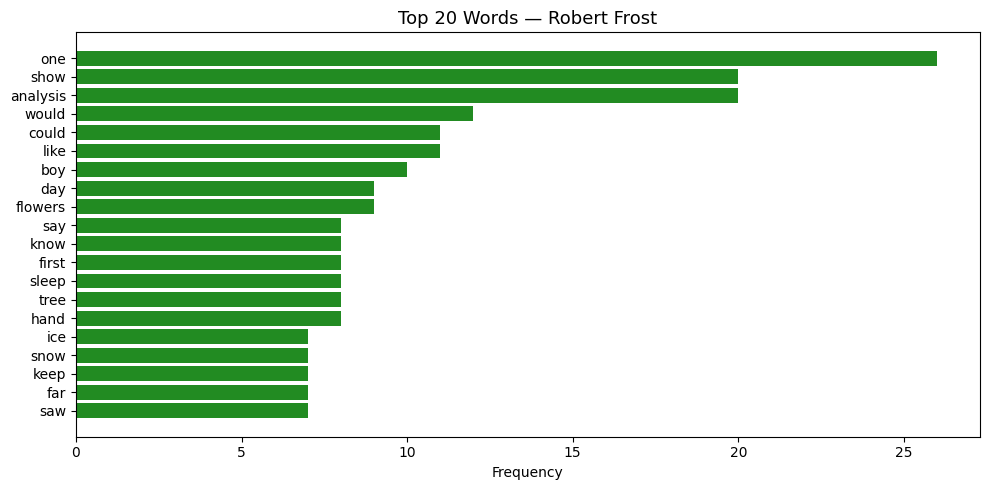

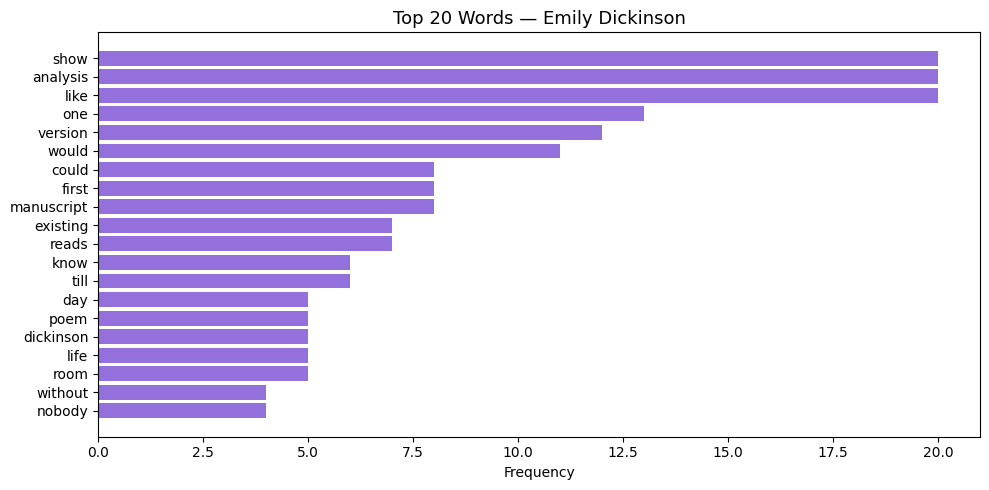


Top words — Robert Frost         Top words — Emily Dickinson
-----------------------------------------------------------------
  one                ( 26 times)     show               ( 20 times)
  show               ( 20 times)     analysis           ( 20 times)
  analysis           ( 20 times)     like               ( 20 times)
  would              ( 12 times)     one                ( 13 times)
  could              ( 11 times)     version            ( 12 times)
  like               ( 11 times)     would              ( 11 times)
  boy                ( 10 times)     could              (  8 times)
  day                (  9 times)     first              (  8 times)
  flowers            (  9 times)     manuscript         (  8 times)
  say                (  8 times)     existing           (  7 times)


In [18]:
def word_freq_plot(texts, poet_name, top_n=20, color='steelblue'):
    """Show the most frequent meaningful words for a poet."""
    all_words = []
    for t in texts:
        tokens = [w for w in word_tokenize(str(t).lower())
                  if w.isalpha() and w not in stop_words and len(w) > 2]
        all_words.extend(tokens)
    freq = Counter(all_words).most_common(top_n)
    words, counts = zip(*freq)
    plt.figure(figsize=(10, 5))
    plt.barh(list(words)[::-1], list(counts)[::-1], color=color)
    plt.title(f'Top {top_n} Words — {poet_name}', fontsize=13)
    plt.xlabel('Frequency')
    plt.tight_layout()
    plt.savefig(store_loc + f'word_freq_{poet_name.replace(" ","_")}.png', dpi=120)
    plt.show()
    return dict(freq)

rf_freq = word_freq_plot(RF_poems_list, poet1, color='forestgreen')
ed_freq = word_freq_plot(ED_poems_list, poet2, color='mediumpurple')

# Print top words side by side for easy comparison
print(f"\n{'Top words — ' + poet1:<32} {'Top words — ' + poet2}")
print("-" * 65)
for (w1, c1), (w2, c2) in zip(list(rf_freq.items())[:10], list(ed_freq.items())[:10]):
    print(f"  {w1:<18} ({c1:>3} times)     {w2:<18} ({c2:>3} times)")

## 🧠 Standard vs Chain of Thought vs Fractal Chain of Thought

In [19]:
if not gemini_model:
    print("⚠️  Gemini not configured — skipping prompting comparison.")
    print("   Add GOOGLE_API_KEY to Colab Secrets to run this section.")
else:
    poem0_human = str(RF_df.iloc[0]['Poem_for_Human'])

    # --- Three prompts on the exact same poem ---

    prompt_standard = (
        f"Transpose this poem by {poet1} into the style of {poet2}. "
        f"Replace nouns, verbs, and adjectives to match {poet2}'s vocabulary and themes.\n\n"
        f"Poem:\n{poem0_human}"
    )

    prompt_cot = (
        f"Transpose this poem by {poet1} into the style of {poet2}. Think step by step:\n"
        f"Step 1: List all the nouns, verbs, and adjectives in the poem.\n"
        f"Step 2: For each word, explain what makes a good replacement in {poet2}'s style.\n"
        f"Step 3: Write out the full transposed poem.\n"
        f"Step 4: Evaluate — does it sound like {poet2}? What could still be improved?\n\n"
        f"Poem:\n{poem0_human}"
    )

    prompt_fcot = (
        f"Transpose this poem by {poet1} into the style of {poet2} using Fractal Chain of Thought.\n\n"
        f"Define two objective functions:\n"
        f"  MAXIMIZE (0-10): How much the result sounds like {poet2}\n"
        f"  MINIMIZE (0-10): How much the original emotional meaning is lost\n\n"
        f"Iteration 1: Make a first attempt. Score it on both objectives.\n"
        f"Iteration 2: Identify what iteration 1 missed. Improve. Re-score.\n"
        f"Iteration 3: Final refinement. Maximize objective 1, minimize objective 2. Re-score.\n"
        f"End with a comparison table of all 3 iterations.\n\n"
        f"Poem:\n{poem0_human}"
    )

    prompts = {'Standard': prompt_standard, 'CoT': prompt_cot, 'FCoT': prompt_fcot}
    outputs = {}

    for label, prompt in prompts.items():
        fname = store_loc + f"hw2_prompt_{label}.txt"
        if os.path.exists(fname):
            with open(fname) as f: outputs[label] = f.read()
            print(f"Loaded {label} from file.")
        else:
            print(f"Running {label} prompt...")
            outputs[label] = gemini_model.generate_content(prompt).text
            with open(fname, 'w') as f: f.write(outputs[label])
            print(f"  Done.")

    # Print all three outputs
    for label, text in outputs.items():
        print(f"\n{'='*62}\n{label} Prompting Result\n{'='*62}")
        print(text[:900] + '...' if len(text) > 900 else text)

    # Similarity comparison — how close is each output to Dickinson's actual poems?
    ed_corpus = ' '.join(ED_poems_list)
    print(f"\n\nSimilarity to {poet2}'s actual poems:")
    print(f"{'Prompt':<12} {'Cosine Similarity':>18} {'Notes'}")
    print("-" * 55)
    notes = {
        'Standard': 'Direct, no reasoning',
        'CoT':      'Step-by-step reasoning',
        'FCoT':     'Iterative with scoring'
    }
    rows = []
    for label, text in outputs.items():
        e1 = sim_model.encode(text[:800], convert_to_tensor=True)
        e2 = sim_model.encode(ed_corpus[:800], convert_to_tensor=True)
        sim = round(util.cos_sim(e1, e2).item(), 4)
        print(f"{label:<12} {sim:>18.4f}  {notes[label]}")
        rows.append({'Prompt': label, 'Sim_to_Poet2': sim, 'Notes': notes[label]})

    pd.DataFrame(rows).to_csv(store_loc + 'hw2_prompt_comparison.csv', index=False)
    print("\nComparison saved to hw2_prompt_comparison.csv")

Running Standard prompt...
  Done.
Running CoT prompt...
  Done.
Running FCoT prompt...
  Done.

Standard Prompting Result
Here is Robert Frost's poem transposed into the style of Emily Dickinson, with an analysis:

**Original Poem by Robert Frost:**

Some say the world will end in fire,
  Some say in ice.
  From what I've tasted of desire
  I hold with those who favor fire.
  But if it had to perish twice,
  I think I know enough of hate
  To say that for destruction ice
  Is also great
  And would suffice.

---

**Transposed Poem in the Style of Emily Dickinson:**

Some whisper – 'Earth's Demise – is Flame –'
Some – 'Chill.'
From what the Soul – has sipped of Zeal –
To Ardor's Cause – I cast my Lot –

But if the Sphere – should twice unmake –
I plumb the Mind – for Frosty Ire –
To yield – that for the Great Undo-ing – Ice –
Is – 'ample' – too –
And would suffice – for Breath's – Annulment –

---

**Analysis of Dickinsonian Elements:**

1.  **Vocabulary:**
    *   **"Earth's Demise"**

## 💭 Reflection — questions to think through

1. **LDA topics:** What themes came up for Frost? For Dickinson? Do they match what you know about these poets?
   - Frost: expect nature, rural life, journeys, seasons
   - Dickinson: expect death, immortality, nature, the soul

2. **Word frequency:** Any surprises in the top words? What's common between them, what's different?

3. **Cosine sim vs Gemini:** Which transposition was more readable? Did Gemini pick better words because it understood the context of the full line?

4. **CoT vs FCoT:** Did the iterative approach in FCoT actually improve the output? Did the scores go up/down across iterations as expected?

5. **Don't just take the LLM's word for it** — read the poems aloud. What sounds natural? What sounds forced?

---
✅ **HW2 complete!** Move on to HW3 next.